In [12]:
# --- COLAB CELL 1 ---
import os
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import joblib

# Automate GitHub Repository Cloning
GITHUB_URL = "https://github.com/justnahid01/K-Means-Clustering-Implementation.git"
REPO_DIR = "K-Means-Clustering-Implementation"

# Clone repo if it hasn't been cloned yet
if not os.path.exists(REPO_DIR):
    !git clone {GITHUB_URL}
else:
    print("Repository already cloned.")

# Create the model directory to save files later
os.makedirs(f"{REPO_DIR}/model", exist_ok=True)
print("Setup complete. Ready to load data.")

Repository already cloned.
Setup complete. Ready to load data.


In [ ]:
# --- COLAB CELL 2 ---
# Load the standard dataset
standard_data_path = f"{REPO_DIR}/dataset/Mall_Customers_Dataset.csv"
df_standard = pd.read_csv(standard_data_path)

# Extract the three required features
X_train = df_standard[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Define and fit the scaling pipeline
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

print("Standard Data loaded and scaled perfectly.")

Standard Data loaded and scaled perfectly.


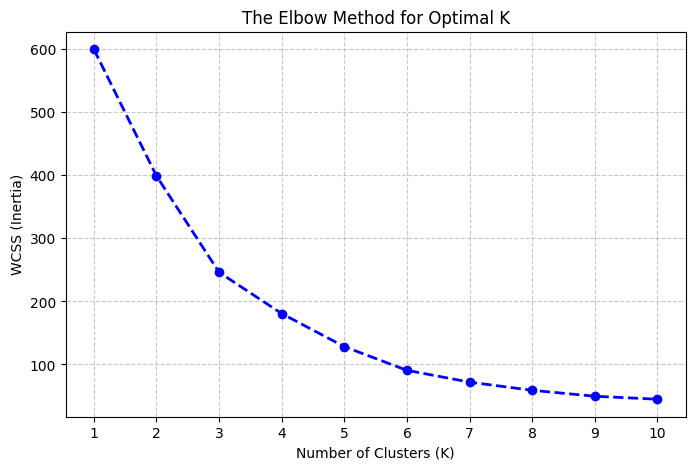

Look for the 'bend' in the graph. For Mall Customers, this is usually at K=5.


In [ ]:
# --- COLAB CELL 3 ---
wcss = []
K_range = range(1, 11)

# Test K from 1 to 10
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    wcss.append(kmeans_temp.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o', linestyle='--', color='blue', linewidth=2)
plt.title('The Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("Look for the 'bend' in the graph. For Mall Customers, this is usually at K=5.")

In [11]:
# --- COLAB CELL 4 ---
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)

# Fit the model
kmeans.fit(X_scaled)

# Assign the predicted clusters back to the original dataframe
df_standard['Cluster'] = kmeans.labels_

# Save the model and scaler objects
model_path = f"{REPO_DIR}/model/kmeans_model.pkl"
scaler_path = f"{REPO_DIR}/model/scaler.pkl"

joblib.dump(kmeans, model_path)
joblib.dump(scaler, scaler_path)

print(f"Success! Model saved to {model_path}")
print("Remember to download these .pkl files from Colab and upload them to your GitHub /model folder!")

Success! Model saved to K-Means-Clustering-Implementation/model/kmeans_model.pkl
Remember to download these .pkl files from Colab and upload them to your GitHub /model folder!


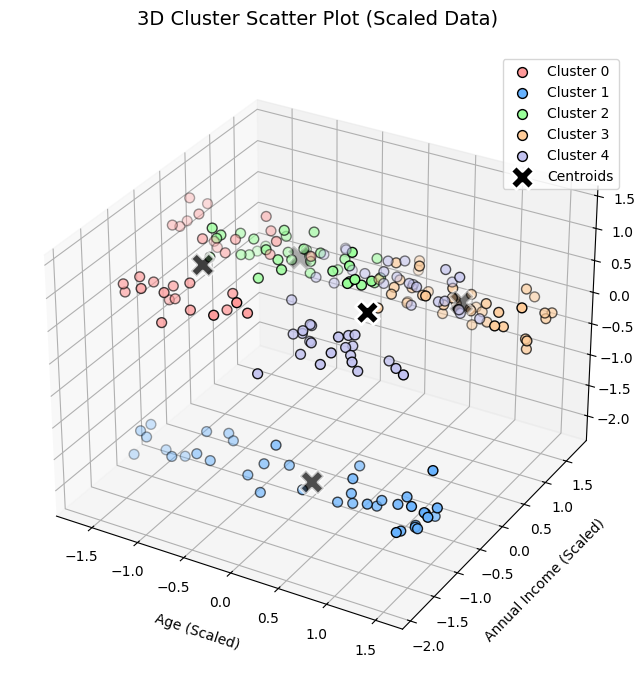

In [ ]:
# --- COLAB CELL 5 ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#c2c2f0']

# Plot each cluster
for i in range(optimal_k):
    cluster_points = X_scaled[df_standard['Cluster'] == i]
    ax.scatter(cluster_points[:, 0], cluster_points[:, 1], cluster_points[:, 2],
               s=50, c=colors[i], edgecolors='k', label=f'Cluster {i}')

# Plot the Centroids
centroids = kmeans.cluster_centers_
ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
           s=300, c='black', marker='X', edgecolors='white', linewidths=2, label='Centroids')

ax.set_title('3D Cluster Scatter Plot (Scaled Data)', fontsize=14, pad=20)
ax.set_xlabel('Age (Scaled)', labelpad=10)
ax.set_ylabel('Annual Income (Scaled)', labelpad=10)
ax.set_zlabel('Spending Score (Scaled)', labelpad=10)
ax.legend()
plt.show()

In [ ]:
# --- UPDATED COLAB CELL 1 ---
import os
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import joblib

# 1. FORCE DELETE the old folder so Colab forgets it
!rm -rf K-Means-Clustering-Implementation

# 2. Download a fresh copy of your repository
GITHUB_URL = "https://github.com/justnahid01/K-Means-Clustering-Implementation.git"
!git clone {GITHUB_URL}

REPO_DIR = "K-Means-Clustering-Implementation"

# Create the model directory
os.makedirs(f"{REPO_DIR}/model", exist_ok=True)
print("\n✅ Setup complete. Fresh repository downloaded!")

Cloning into 'K-Means-Clustering-Implementation'...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 7 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (7/7), done.

✅ Setup complete. Fresh repository downloaded!


Cluster Interpretation Profile
Based on the dataset features and the calculated centroids, the K-Means pipeline grouped the subjects into five distinct categories:

Cluster 0: Individuals with lower incomes and lower spending scores.

Cluster 1: Middle-aged individuals with moderate income and moderate spending habits.

Cluster 2: Younger, low-income subjects who possess a very high spending score.

Cluster 3: Younger, high-income subjects who also spend heavily, indicating a target demographic for premium goods.

Cluster 4: High-income, low-spending subjects who are conservative with their resources.